# Dependencies
Make sure to install scattering package for access

In [2]:
import numpy as np
from kymatio.scattering3d.backend.torch_backend import TorchBackend3D
from matplotlib import pyplot as plt
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import torch

from scripts.fit_models import get_folds
from wavelets import solid_harmonic_filter_bank, SolidHarmonicModel

# Solid Harmonic Wavelets in 2D

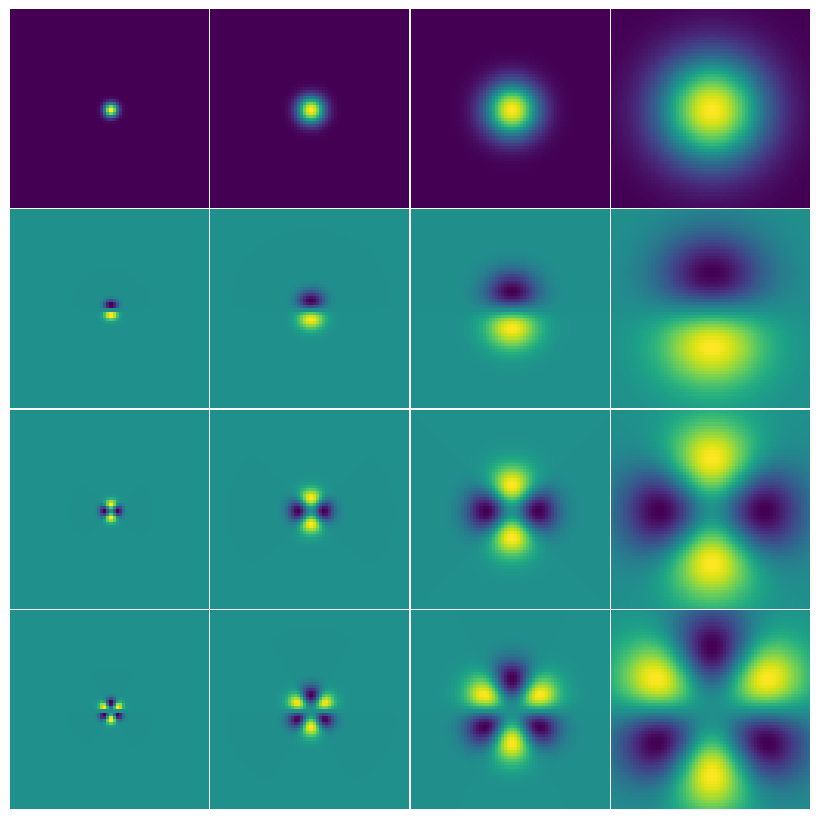

In [4]:
L, J = 3, 3
M, N = 64, 64
sigma_0 = 1.5
filters = solid_harmonic_filter_bank(M, N, J, L, sigma_0, fourier=False)

fig, axs = plt.subplots(L + 1, J + 1, figsize=(8, 8))

for l in range(L + 1):
    for j in range(J + 1):
        ax = axs[l, j]
        ax.axis('off')
        ax.imshow(np.real(filters[l][j]), cmap='viridis')

plt.subplots_adjust(left=0, right=1, bottom=0, top=1, wspace=0.01, hspace=0.01)
plt.show()

# Sample Experiment

In [13]:
L = 8
J = 3
sigma = 0.5
lp = [0.5, 1, 2, 4]

type = "scattering"  # use this line for shws, shwsb, shwsbic
# type = "shwb" # use for shwb, shwbic
scattering_config = {
    "L": L,
    "J": J,
    "sigma": sigma,
    "lp_norms": lp,
    "bispectrum": True,
    "bicoherence": True,
    "reduce": True
}
higher_order_config = {
    "L": L,
    "J": J,
    "sigma": sigma,
    "lp_norms": lp,
    "bicoherence": True,
}

### Load data

In [14]:
# Load data
data = np.load("")  #npz dataset path
X_train, y_train = data['train_images'].astype("float32"), data['train_labels'].ravel()
X_val, y_val = data['val_images'].astype("float32"), data['val_labels'].ravel()
X_test, y_test = data['test_images'].astype("float32"), data['test_labels'].ravel()

X_train = X_train.reshape(X_train.shape[0], X_train.shape[-1], X_train.shape[1], X_train.shape[2])
X_val = X_val.reshape(X_val.shape[0], X_val.shape[-1], X_val.shape[1], X_val.shape[2])
X_test = X_test.reshape(X_test.shape[0], X_test.shape[-1], X_test.shape[1], X_test.shape[2])

X_train /= 255.0
X_val /= 255.0
X_test /= 255.0

X_train = np.concatenate([X_train, X_val], axis=0)
y_train = np.concatenate([y_train, y_val], axis=0)
M = X_train.shape[-1]
N = M

### Generate coefficients

In [15]:
strategies = {
    "scattering": lambda batch, scat: scat.scatter(batch), # SHWS, SHWSB, SHWSBic
    "shwb": lambda batch, scat: scat.bispectrum(batch), # SHWB, SHWBic
}

def generate_coefficients(data, model, type="scattering"):
    batch_size = 32
    n_samples = len(data)
    n_batches = int(np.ceil(n_samples / batch_size))

    order_0, orders_1_2 = [], []
    for i in range(n_batches):
        start = i * batch_size
        end = min(start + batch_size, n_samples)

        batch = torch.from_numpy(data[start:end])
        zeroth_order = TorchBackend3D.compute_integrals(batch, lp)
        order_0.append(zeroth_order.cpu().numpy())

        first_second_orders = strategies.get(type)(batch, model)
        orders_1_2.append(first_second_orders.cpu().numpy())

    order_0 = np.concatenate(order_0, axis=0)
    orders_1_2 = np.concatenate(orders_1_2, axis=0)

    return np.concatenate([order_0, orders_1_2], axis=1)

coefficient_model = SolidHarmonicModel(M=M, N=N, scattering_config=scattering_config,
                                          higher_order_config=higher_order_config)
train_coef = generate_coefficients(X_train, coefficient_model)
test_coef = generate_coefficients(X_test, coefficient_model)
cross_val_folds = get_folds(train_coef)

### Run the experiment

In [16]:
# Run the experiment
param_grid = {
    # DEFINE HYPERPARAMETERS HERE
    "classifier__alpha": [0.00001, 0.001, 0.1, 2, 10, 100]
}

pipeline = Pipeline([
    ('scaler', StandardScaler()),  # normalise dataset
    ('classifier', RidgeClassifier(solver="svd")),
])

grid_search = GridSearchCV(pipeline, param_grid, cv=cross_val_folds)
grid_search.fit(train_coef, y_train)

best_model = grid_search.best_estimator_

target_prediction = best_model.predict(test_coef)
print(f"Accuracy: {accuracy_score(y_test, target_prediction):.4f}")

Accuracy: 0.7222
